# Workshop 3 — Exploratory Data Analysis (EDA)
## World Happiness Report 2015–2019

**Course:** ETL (G01) | **Program:** Data Engineering & AI  
**Part A — Step 1:** Data Profiling, Cleaning & Schema Harmonization

---

### Objectives
- Profile each dataset individually (missing values, duplicates, dtypes, outliers)
- Identify schema differences across years
- Propose and implement a unified analytical schema
- Export a clean, harmonized dataset for ML training

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Global plot style: black background, vivid colors ──────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d0d0d',
    'axes.facecolor':   '#0d0d0d',
    'axes.edgecolor':   '#444444',
    'axes.labelcolor':  '#f0f0f0',
    'xtick.color':      '#f0f0f0',
    'ytick.color':      '#f0f0f0',
    'text.color':       '#f0f0f0',
    'grid.color':       '#2a2a2a',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'legend.facecolor': '#1a1a1a',
    'legend.edgecolor': '#444444',
    'figure.dpi':       120,
})

NEON_PALETTE = ['#00f5d4', '#f72585', '#7209b7', '#3a86ff', '#ffbe0b',
                '#fb5607', '#8338ec', '#06d6a0']

RAW_DIR = '../data/raw/'
PROCESSED_DIR = '../data/processed/'

print('Libraries loaded. Plot style: dark + neon.')

Libraries loaded. Plot style: dark + neon.


---
## 1. Load Raw Datasets

In [2]:
years = [2015, 2016, 2017, 2018, 2019]
raw = {}

for y in years:
    df = pd.read_csv(f'{RAW_DIR}{y}.csv')
    raw[y] = df
    print(f'{y}: {df.shape[0]} rows × {df.shape[1]} cols')

2015: 158 rows × 12 cols
2016: 157 rows × 13 cols
2017: 155 rows × 12 cols
2018: 156 rows × 9 cols
2019: 156 rows × 9 cols


---
## 2. Schema Comparison Across Years

This is the central challenge: the five datasets were published in different formats with inconsistent column naming conventions.

In [3]:
print('=' * 70)
for y in years:
    print(f'\n[{y}] Columns ({len(raw[y].columns)}):')
    for col in raw[y].columns:
        print(f'  - {col} ({raw[y][col].dtype})')
print('=' * 70)


[2015] Columns (12):
  - Country (str)
  - Region (str)
  - Happiness Rank (int64)
  - Happiness Score (float64)
  - Standard Error (float64)
  - Economy (GDP per Capita) (float64)
  - Family (float64)
  - Health (Life Expectancy) (float64)
  - Freedom (float64)
  - Trust (Government Corruption) (float64)
  - Generosity (float64)
  - Dystopia Residual (float64)

[2016] Columns (13):
  - Country (str)
  - Region (str)
  - Happiness Rank (int64)
  - Happiness Score (float64)
  - Lower Confidence Interval (float64)
  - Upper Confidence Interval (float64)
  - Economy (GDP per Capita) (float64)
  - Family (float64)
  - Health (Life Expectancy) (float64)
  - Freedom (float64)
  - Trust (Government Corruption) (float64)
  - Generosity (float64)
  - Dystopia Residual (float64)

[2017] Columns (12):
  - Country (str)
  - Happiness.Rank (int64)
  - Happiness.Score (float64)
  - Whisker.high (float64)
  - Whisker.low (float64)
  - Economy..GDP.per.Capita. (float64)
  - Family (float64)
  - Healt

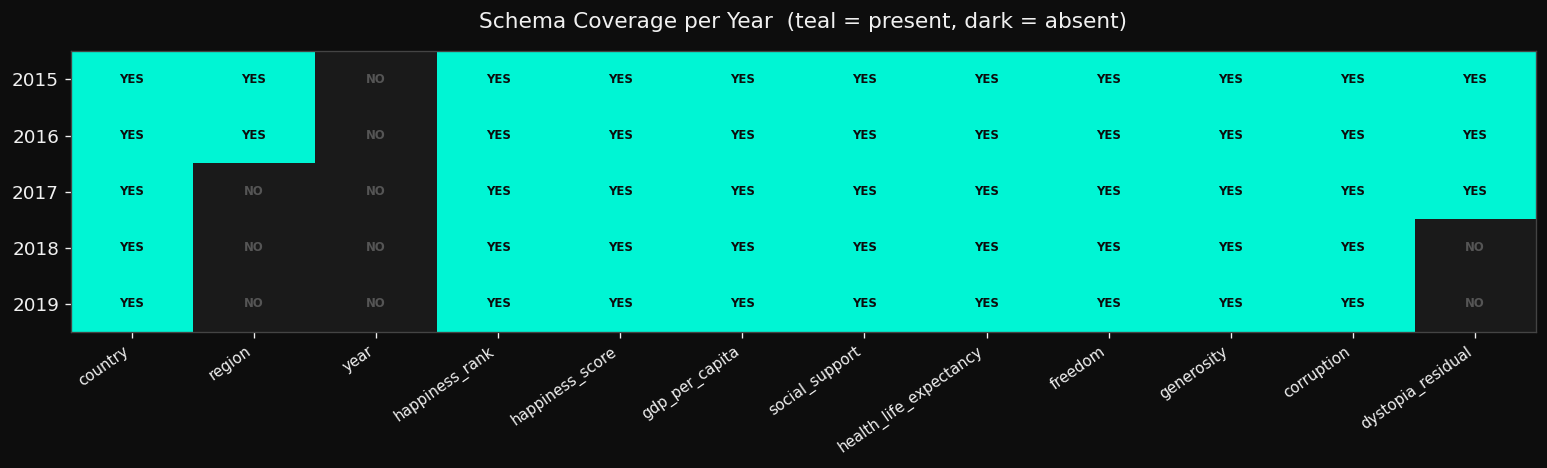

Saved: schema_coverage.png


In [4]:
# Visual schema difference heatmap
UNIFIED_COLS = [
    'country', 'region', 'year', 'happiness_rank', 'happiness_score',
    'gdp_per_capita', 'social_support', 'health_life_expectancy',
    'freedom', 'generosity', 'corruption', 'dystopia_residual'
]

presence = {
    2015: [1,1,0,1,1,1,1,1,1,1,1,1],
    2016: [1,1,0,1,1,1,1,1,1,1,1,1],
    2017: [1,0,0,1,1,1,1,1,1,1,1,1],
    2018: [1,0,0,1,1,1,1,1,1,1,1,0],
    2019: [1,0,0,1,1,1,1,1,1,1,1,0],
}

presence_df = pd.DataFrame(presence, index=UNIFIED_COLS).T

fig, ax = plt.subplots(figsize=(13, 4))
cmap = plt.cm.colors.ListedColormap(['#1a1a1a', '#00f5d4'])
im = ax.imshow(presence_df.values, cmap=cmap, aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(UNIFIED_COLS)))
ax.set_xticklabels(UNIFIED_COLS, rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(len(years)))
ax.set_yticklabels(years, fontsize=11)
ax.set_title('Schema Coverage per Year  (teal = present, dark = absent)', 
             fontsize=13, pad=14, color='#f0f0f0')
for i in range(len(years)):
    for j in range(len(UNIFIED_COLS)):
        val = presence_df.values[i, j]
        txt = 'YES' if val else 'NO'
        color = '#0d0d0d' if val else '#555555'
        ax.text(j, i, txt, ha='center', va='center', fontsize=7, color=color, fontweight='bold')
fig.tight_layout()
plt.savefig('../data/processed/schema_coverage.png', bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print('Saved: schema_coverage.png')

---
## 3. Individual Dataset Profiling

In [5]:
def profile_dataset(df, year):
    print(f'\n{"="*60}')
    print(f'  PROFILING — {year}')
    print(f'{"="*60}')
    print(f'Shape            : {df.shape[0]} rows × {df.shape[1]} cols')
    print(f'Duplicate rows   : {df.duplicated().sum()}')
    print(f'\nMissing values per column:')
    null_info = df.isnull().sum()
    null_pct  = (df.isnull().sum() / len(df) * 100).round(2)
    null_df   = pd.DataFrame({'Missing': null_info, 'Pct (%)': null_pct})
    print(null_df[null_df['Missing'] > 0].to_string() if null_df['Missing'].sum() > 0 else '  None')
    print(f'\nDescriptive Statistics:')
    print(df.describe().round(4).to_string())

for y in years:
    profile_dataset(raw[y], y)


  PROFILING — 2015
Shape            : 158 rows × 12 cols
Duplicate rows   : 0

Missing values per column:
  None

Descriptive Statistics:
       Happiness Rank  Happiness Score  Standard Error  Economy (GDP per Capita)    Family  Health (Life Expectancy)   Freedom  Trust (Government Corruption)  Generosity  Dystopia Residual
count        158.0000         158.0000        158.0000                  158.0000  158.0000                  158.0000  158.0000                       158.0000    158.0000           158.0000
mean          79.4937           5.3757          0.0479                    0.8461    0.9910                    0.6303    0.4286                         0.1434      0.2373             2.0990
std           45.7544           1.1450          0.0171                    0.4031    0.2724                    0.2471    0.1507                         0.1200      0.1267             0.5535
min            1.0000           2.8390          0.0185                    0.0000    0.0000               

---
## 4. Missing Values Visualization

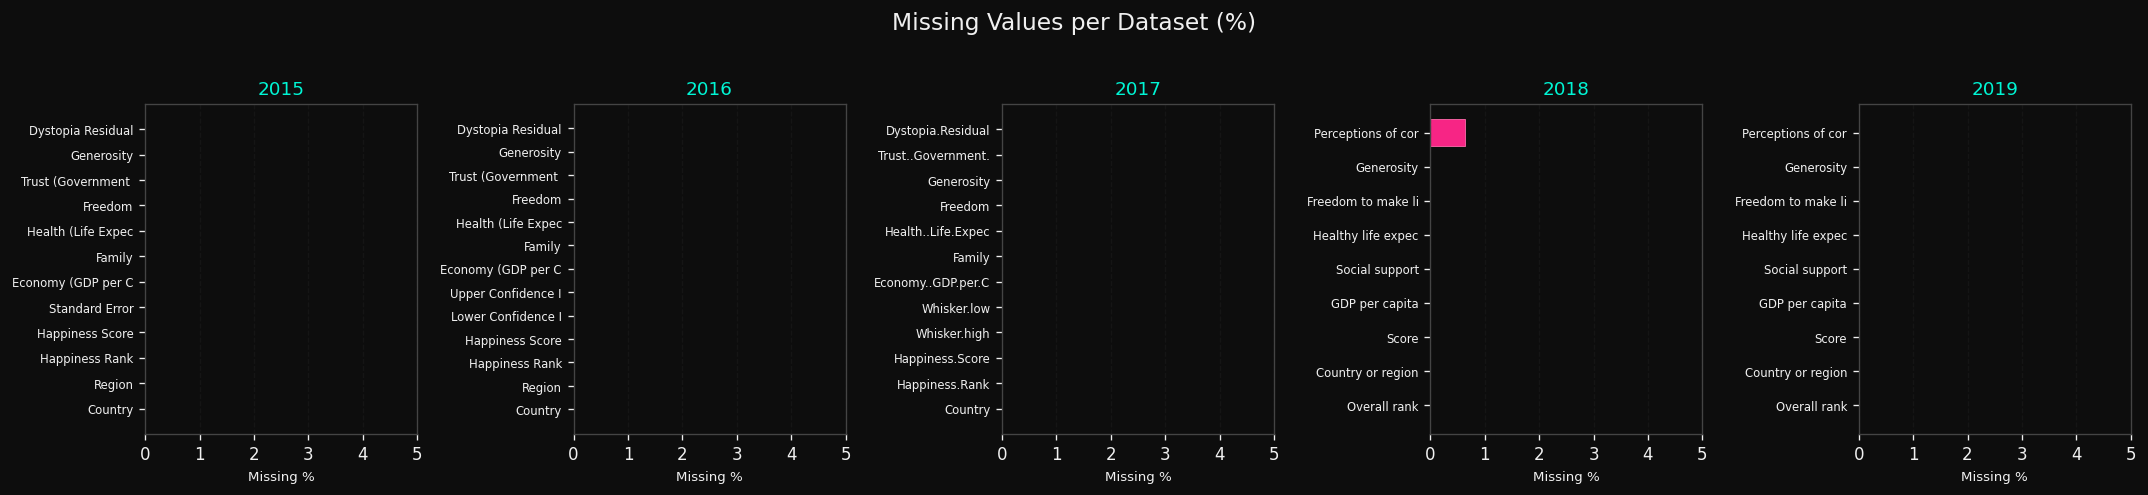

Observation: Only 2018 has 1 missing value in "Perceptions of corruption" (0.64%)


In [6]:
# 2018 has 1 missing value in 'Perceptions of corruption'
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for idx, y in enumerate(years):
    df = raw[y]
    null_pct = (df.isnull().sum() / len(df) * 100)
    bars = axes[idx].barh(range(len(df.columns)), null_pct.values,
                          color='#f72585', edgecolor='#ff6bac', linewidth=0.5)
    axes[idx].set_yticks(range(len(df.columns)))
    axes[idx].set_yticklabels([c[:18] for c in df.columns], fontsize=7)
    axes[idx].set_xlabel('Missing %', fontsize=8)
    axes[idx].set_title(str(y), fontsize=11, color='#00f5d4')
    axes[idx].set_xlim(0, 5)
    axes[idx].grid(axis='x', alpha=0.3)

fig.suptitle('Missing Values per Dataset (%)', fontsize=14, y=1.02, color='#f0f0f0')
fig.tight_layout()
plt.savefig('../data/processed/missing_values.png', bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print('Observation: Only 2018 has 1 missing value in "Perceptions of corruption" (0.64%)')

---
## 5. Outlier Analysis — Box Plots

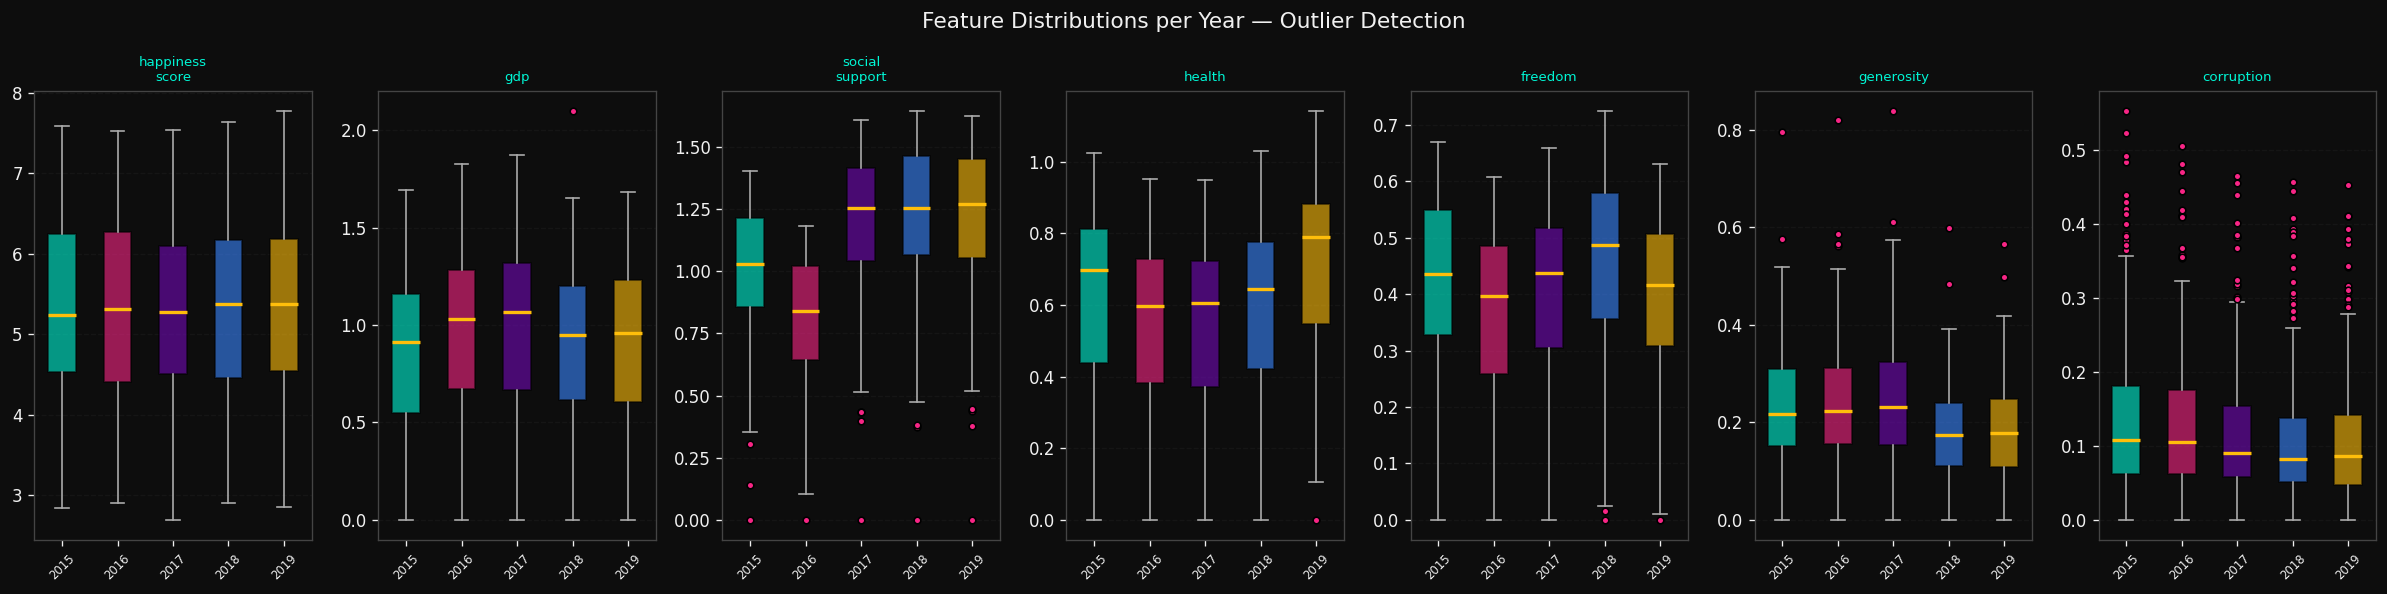

Observation: No extreme outliers detected. Generosity and corruption show slightly wider tails.


In [7]:
# Map each year's numeric features to unified names for comparison
COL_MAP = {
    2015: {'Happiness Score': 'happiness_score', 'Economy (GDP per Capita)': 'gdp',
           'Family': 'social_support', 'Health (Life Expectancy)': 'health',
           'Freedom': 'freedom', 'Generosity': 'generosity',
           'Trust (Government Corruption)': 'corruption'},
    2016: {'Happiness Score': 'happiness_score', 'Economy (GDP per Capita)': 'gdp',
           'Family': 'social_support', 'Health (Life Expectancy)': 'health',
           'Freedom': 'freedom', 'Generosity': 'generosity',
           'Trust (Government Corruption)': 'corruption'},
    2017: {'Happiness.Score': 'happiness_score', 'Economy..GDP.per.Capita.': 'gdp',
           'Family': 'social_support', 'Health..Life.Expectancy.': 'health',
           'Freedom': 'freedom', 'Generosity': 'generosity',
           'Trust..Government.Corruption.': 'corruption'},
    2018: {'Score': 'happiness_score', 'GDP per capita': 'gdp',
           'Social support': 'social_support', 'Healthy life expectancy': 'health',
           'Freedom to make life choices': 'freedom', 'Generosity': 'generosity',
           'Perceptions of corruption': 'corruption'},
    2019: {'Score': 'happiness_score', 'GDP per capita': 'gdp',
           'Social support': 'social_support', 'Healthy life expectancy': 'health',
           'Freedom to make life choices': 'freedom', 'Generosity': 'generosity',
           'Perceptions of corruption': 'corruption'},
}

# Build a combined df with harmonized names
frames = []
for y in years:
    subset = raw[y][list(COL_MAP[y].keys())].rename(columns=COL_MAP[y]).copy()
    subset['year'] = y
    frames.append(subset)
combined_preview = pd.concat(frames, ignore_index=True)

features = ['happiness_score','gdp','social_support','health','freedom','generosity','corruption']
fig, axes = plt.subplots(1, len(features), figsize=(20, 5))

for idx, feat in enumerate(features):
    data_by_year = [combined_preview[combined_preview['year']==y][feat].dropna().values for y in years]
    bp = axes[idx].boxplot(data_by_year, labels=years, patch_artist=True,
                           medianprops=dict(color='#ffbe0b', linewidth=2),
                           whiskerprops=dict(color='#aaaaaa'),
                           capprops=dict(color='#aaaaaa'),
                           flierprops=dict(marker='o', markerfacecolor='#f72585', markersize=4))
    for patch, color in zip(bp['boxes'], NEON_PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    axes[idx].set_title(feat.replace('_', '\n'), fontsize=8, color='#00f5d4')
    axes[idx].set_xticklabels(years, rotation=45, fontsize=7)
    axes[idx].grid(axis='y', alpha=0.3)

fig.suptitle('Feature Distributions per Year — Outlier Detection', fontsize=13, color='#f0f0f0')
fig.tight_layout()
plt.savefig('../data/processed/outlier_boxplots.png', bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print('Observation: No extreme outliers detected. Generosity and corruption show slightly wider tails.')

---
## 6. Correlation Analysis

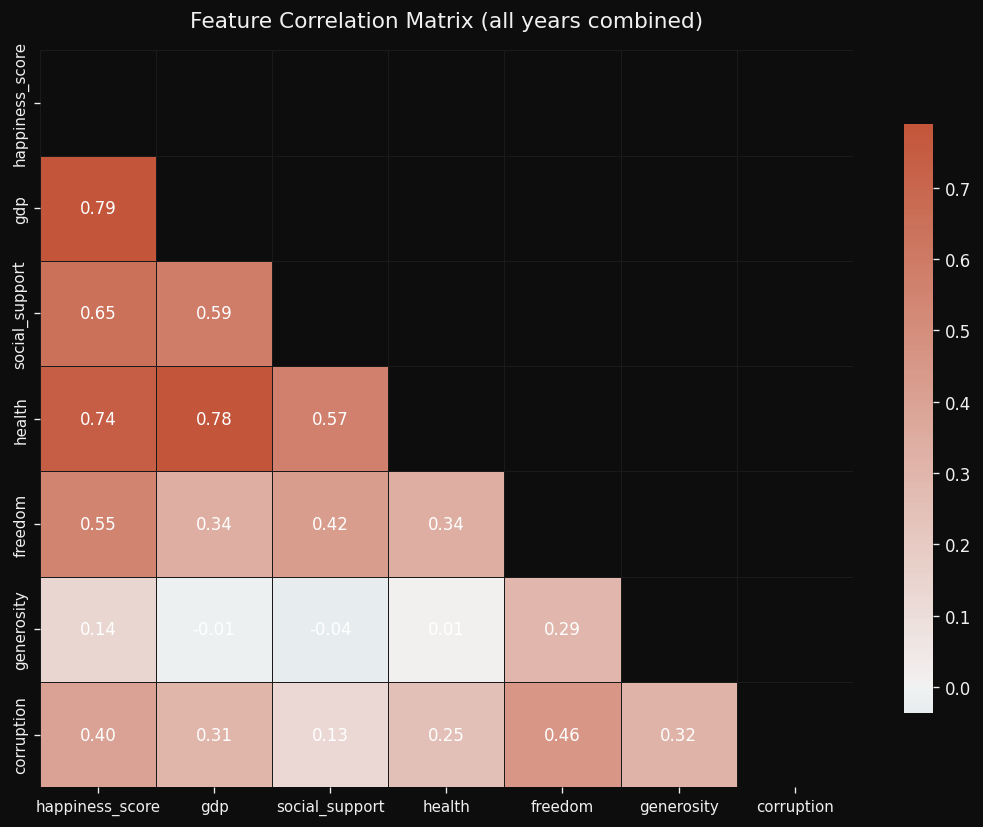

Key insight: GDP, health, social_support show the strongest correlation with happiness_score.
Generosity and corruption show the weakest correlation.


In [8]:
corr = combined_preview[features].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, center=0,
            annot=True, fmt='.2f', annot_kws={'size': 10, 'color': 'white'},
            linewidths=0.5, linecolor='#1a1a1a',
            cbar_kws={'shrink': 0.8}, ax=ax)

ax.set_title('Feature Correlation Matrix (all years combined)', fontsize=13, pad=14, color='#f0f0f0')
ax.tick_params(labelsize=9)
fig.tight_layout()
plt.savefig('../data/processed/correlation_heatmap.png', bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

print('Key insight: GDP, health, social_support show the strongest correlation with happiness_score.')
print('Generosity and corruption show the weakest correlation.')

---
## 7. Happiness Score Distribution per Year

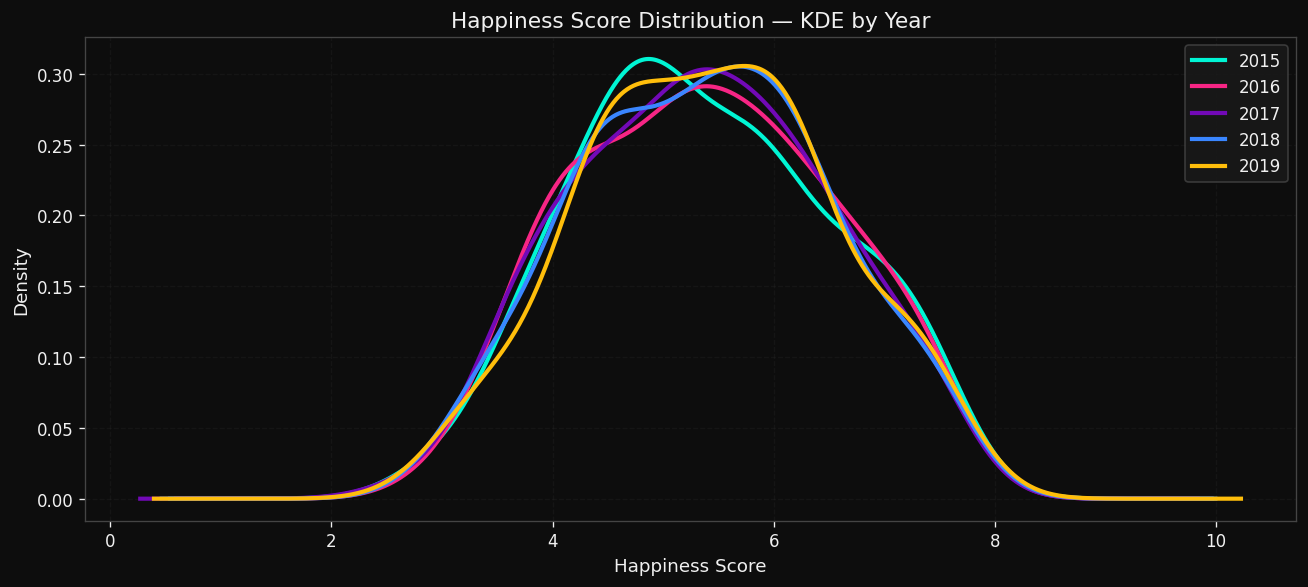

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))

for idx, y in enumerate(years):
    scores = combined_preview[combined_preview['year']==y]['happiness_score'].dropna()
    scores.plot.kde(ax=ax, color=NEON_PALETTE[idx], linewidth=2.5, label=str(y))

ax.set_title('Happiness Score Distribution — KDE by Year', fontsize=13, color='#f0f0f0')
ax.set_xlabel('Happiness Score', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.savefig('../data/processed/happiness_kde.png', bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

---
## 8. Data Cleaning & Harmonization

### Unified Schema Proposal

| Unified Column | Source (2015/2016) | Source (2017) | Source (2018/2019) |
|---|---|---|---|
| `country` | Country | Country | Country or region |
| `region` | Region | *(absent — NaN)* | *(absent — NaN)* |
| `year` | *(injected)* | *(injected)* | *(injected)* |
| `happiness_rank` | Happiness Rank | Happiness.Rank | Overall rank |
| `happiness_score` | Happiness Score | Happiness.Score | Score |
| `gdp_per_capita` | Economy (GDP per Capita) | Economy..GDP.per.Capita. | GDP per capita |
| `social_support` | Family | Family | Social support |
| `health_life_expectancy` | Health (Life Expectancy) | Health..Life.Expectancy. | Healthy life expectancy |
| `freedom` | Freedom | Freedom | Freedom to make life choices |
| `generosity` | Generosity | Generosity | Generosity |
| `corruption` | Trust (Government Corruption) | Trust..Government.Corruption. | Perceptions of corruption |
| `dystopia_residual` | Dystopia Residual | Dystopia.Residual | *(absent — NaN)* |

### Cleaning Decisions Justified:
- **`region` (2017–2019):** Set to NaN — not available in source; will NOT be used as ML feature
- **`dystopia_residual` (2018–2019):** Set to NaN — absent from source; excluded from features
- **Confidence interval / Whisker columns (2015, 2016, 2017):** Dropped — not available in all years and not relevant to prediction
- **Standard Error (2015):** Dropped — not available in other years
- **1 missing value in 2018 `corruption`:** Imputed with median of that year — only 0.64% of rows

In [10]:
def harmonize(df, year):
    """
    Maps raw columns to unified schema and injects year.
    Returns a DataFrame with standardized column names.
    """
    if year in (2015, 2016):
        out = pd.DataFrame({
            'country':               df['Country'],
            'region':                df['Region'],
            'year':                  year,
            'happiness_rank':        df['Happiness Rank'],
            'happiness_score':       df['Happiness Score'],
            'gdp_per_capita':        df['Economy (GDP per Capita)'],
            'social_support':        df['Family'],
            'health_life_expectancy':df['Health (Life Expectancy)'],
            'freedom':               df['Freedom'],
            'generosity':            df['Generosity'],
            'corruption':            df['Trust (Government Corruption)'],
            'dystopia_residual':     df['Dystopia Residual'],
        })
    elif year == 2017:
        out = pd.DataFrame({
            'country':               df['Country'],
            'region':                np.nan,
            'year':                  year,
            'happiness_rank':        df['Happiness.Rank'],
            'happiness_score':       df['Happiness.Score'],
            'gdp_per_capita':        df['Economy..GDP.per.Capita.'],
            'social_support':        df['Family'],
            'health_life_expectancy':df['Health..Life.Expectancy.'],
            'freedom':               df['Freedom'],
            'generosity':            df['Generosity'],
            'corruption':            df['Trust..Government.Corruption.'],
            'dystopia_residual':     df['Dystopia.Residual'],
        })
    else:  # 2018, 2019
        out = pd.DataFrame({
            'country':               df['Country or region'],
            'region':                np.nan,
            'year':                  year,
            'happiness_rank':        df['Overall rank'],
            'happiness_score':       df['Score'],
            'gdp_per_capita':        df['GDP per capita'],
            'social_support':        df['Social support'],
            'health_life_expectancy':df['Healthy life expectancy'],
            'freedom':               df['Freedom to make life choices'],
            'generosity':            df['Generosity'],
            'corruption':            df['Perceptions of corruption'],
            'dystopia_residual':     np.nan,
        })
    return out

harmonized = [harmonize(raw[y], y) for y in years]
unified = pd.concat(harmonized, ignore_index=True)

# Handle the 1 null in 2018 corruption
median_2018_corruption = unified[unified['year']==2018]['corruption'].median()
unified['corruption'] = unified['corruption'].fillna(median_2018_corruption)

# Standardize country names (strip whitespace)
unified['country'] = unified['country'].str.strip()
unified['region']  = unified['region'].str.strip() if unified['region'].dtype == object else unified['region']

# Enforce correct dtypes
unified['year']           = unified['year'].astype(int)
unified['happiness_rank'] = unified['happiness_rank'].astype(int)

print(f'Unified dataset shape: {unified.shape}')
print(f'\nMissing values after cleaning:')
print(unified.isnull().sum())
print(f'\nDuplicate rows: {unified.duplicated().sum()}')
print(f'\nYears present: {sorted(unified["year"].unique())}')
print(f'Countries: {unified["country"].nunique()}')

Unified dataset shape: (782, 12)

Missing values after cleaning:
country                     0
region                    467
year                        0
happiness_rank              0
happiness_score             0
gdp_per_capita              0
social_support              0
health_life_expectancy      0
freedom                     0
generosity                  0
corruption                  0
dystopia_residual         312
dtype: int64

Duplicate rows: 0

Years present: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]
Countries: 170


In [ ]:
unified.head(10)

---
## 9. Final Data Quality Summary

In [11]:
import os
os.makedirs('../data/processed', exist_ok=True)

unified.to_csv('../data/processed/unified_happiness.csv', index=False)
print('Saved: data/processed/unified_happiness.csv')

print(f'\n--- FINAL UNIFIED DATASET SUMMARY ---')
print(f'Total rows     : {len(unified)}')
print(f'Total columns  : {len(unified.columns)}')
print(f'Years covered  : 2015 – 2019')
print(f'Countries      : {unified["country"].nunique()}')
print(f'Remaining nulls: {unified.isnull().sum().sum()} (region/dystopia_residual intentionally NaN for 2017–2019)')
print(f'Numeric features for ML: gdp_per_capita, social_support, health_life_expectancy, freedom, generosity, corruption')
print(f'Target variable: happiness_score')
unified.dtypes

Saved: data/processed/unified_happiness.csv

--- FINAL UNIFIED DATASET SUMMARY ---
Total rows     : 782
Total columns  : 12
Years covered  : 2015 – 2019
Countries      : 170
Remaining nulls: 779 (region/dystopia_residual intentionally NaN for 2017–2019)
Numeric features for ML: gdp_per_capita, social_support, health_life_expectancy, freedom, generosity, corruption
Target variable: happiness_score


country                       str
region                     object
year                        int64
happiness_rank              int64
happiness_score           float64
gdp_per_capita            float64
social_support            float64
health_life_expectancy    float64
freedom                   float64
generosity                float64
corruption                float64
dystopia_residual         float64
dtype: object

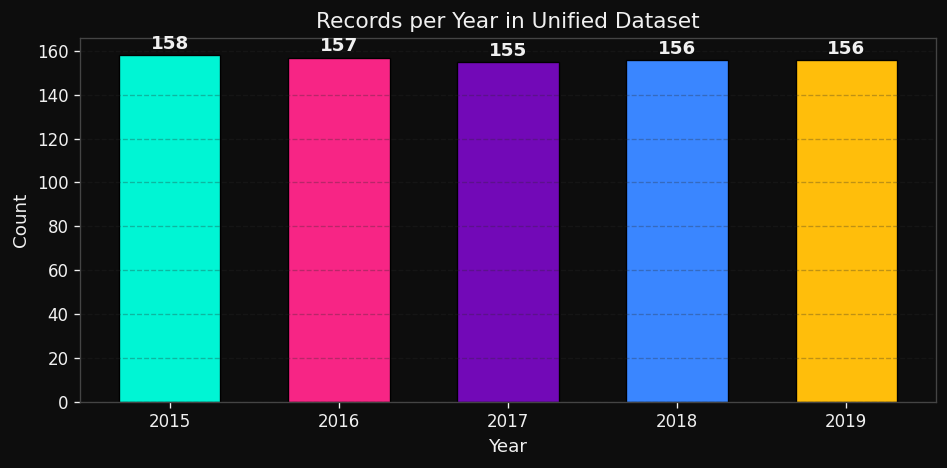

EDA complete. Proceed to model_training.ipynb


In [12]:
# Records per year bar chart
counts = unified.groupby('year').size()
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(counts.index, counts.values, color=NEON_PALETTE[:5], edgecolor='#000', linewidth=0.8, width=0.6)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val),
            ha='center', va='bottom', fontsize=11, color='#f0f0f0', fontweight='bold')
ax.set_title('Records per Year in Unified Dataset', fontsize=13, color='#f0f0f0')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_xticks(counts.index)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.savefig('../data/processed/records_per_year.png', bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print('EDA complete. Proceed to model_training.ipynb')